In [1]:
from spubase.data_access import Particles
import pandas as pd

# Initialize SpuBase

In [2]:
SpuBase = Particles(verbose=True, show_plot=False)  # create object (acts as 'self' and is used to call globals)

Model: sbbx
SW fraction is 96% H+ and 4% He2+
DB directory: C:\Users\couro\Dokumente\GitHub\SpuBase\spubase\docs


#### Setup usrface mineral fractions

In [3]:
SpuBase.casename = 'Feldspar'  # name that is used for output folder and files

mineraldict = {'Ab':0.33, 'An':0.33, 'Or':0.33} # mineral short forms and their fractions given as dictionary
minfrac = pd.DataFrame.from_dict(mineraldict, orient='index', columns=['frac'])

#### Optional Inputs

In [4]:
# SpuBase.update_file_format('pdf') # plot format, choose between 'pdf', 'png', 'svg', 'tiff'
# SpuBase.update_impactor('H', comp_frac=[1.00, 0.00])  # either 1 keV H ('H'), 4 keV He ('He') or both ('SW'); comp_frac: different mixture of H, He (Significantly effects yield and angular distribution!)
# SpuBase.sulfur_diffusion = False  # turns off S diffusion in sulfides (gets turned off automatically if impactor != 'SW')
# SpuBase.v_esc = 2380 # m/s  escape velocity of irradiated body
# SpuBase.return_amu_ion = True  # plot total mass yield in amu/ion instead of atomic yields
# SpuBase.is_summed_up = False  # return result for each individual species separately instead of summing components

#### Change ouput directory to DATABASE/output/casename

In [5]:
SpuBase.update_directory()

Directory already exists:
C:\Users\couro\Dokumente\GitHub\SpuBase\spubase\output\Feldspar


#### Pass surface composition to SpuBase and call data

In [6]:
SpuBase.surface_composition(minfrac.T, form='vol%')  # other options are 'wt%' or 'mol%'
SpuBase.minfrac_a


Sum of mineral data available in SpuBase is 1.00/1.00



[0.33333333333333337, 0.33333333333333337, 0.33333333333333337]

#### Create DataFrame based on input

In [7]:
SpuBase.data_series()


Sum up particles from minerals and perform a re-fit
Progress:
0.0% O
2.9%
6.5%
10.1%
13.8%
16.7% Na
19.6%
23.2%
26.8%
30.4%
33.3% Al
36.2%
39.9%
43.5%
47.1%
50.0% Si
52.9%
56.5%
60.1%
63.8%
66.7% K
69.6%
73.2%
76.8%
80.4%
83.3% Ca
86.2%
89.9%
93.5%
97.1%
Data exported as .csv to C:\Users\couro\Dokumente\GitHub\SpuBase\spubase\output\Feldspar\SW_Feldspar_particle_data_Ab0.33An0.33Or0.33.txt
Data for Feldspar created



In [8]:
SpuBase.yield_df  # yield gets written into the output file together with the particle angular and energy fit parameter

,O,Na,Al,Si,K,Ca
alpha,,,,,,
0,0.008878,0.000378,0.001563,0.003031,0.000364,0.000400
1,0.008883,0.000378,0.001564,0.003032,0.000364,0.000400
2,0.008894,0.000378,0.001566,0.003036,0.000364,0.000400
3,0.008914,0.000379,0.001569,0.003043,0.000365,0.000401
4,0.008940,0.000380,0.001574,0.003051,0.000366,0.000402
...,...,...,...,...,...,...
85,0.075472,0.003238,0.012422,0.025483,0.003273,0.002928
86,0.052034,0.002255,0.008442,0.017566,0.002308,0.001945
87,0.027193,0.001200,0.004272,0.009107,0.001236,0.000958


#### Plot data

Plotting yield


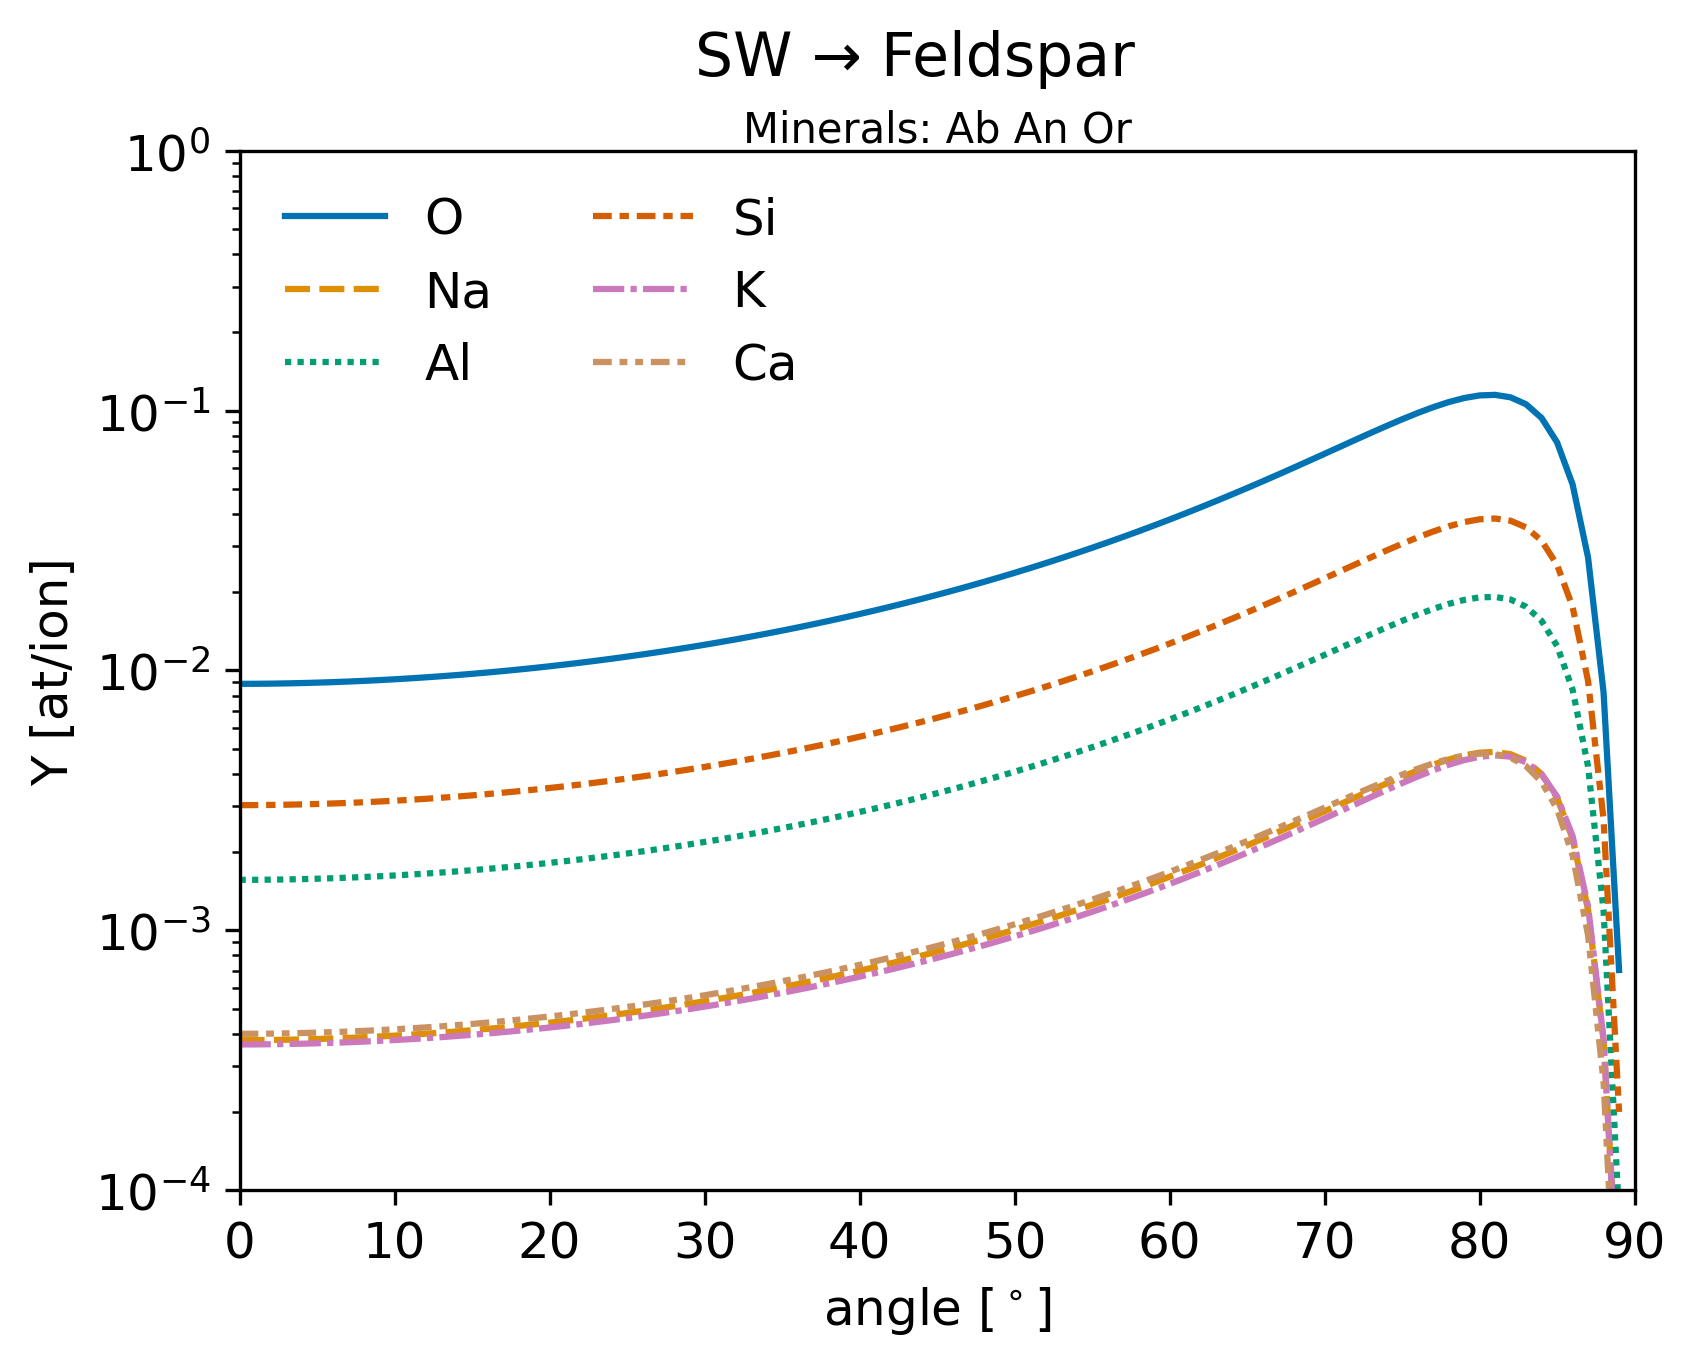

In [9]:
fig, ax = SpuBase.plot_yield()
fig

#### Set up plotting parameters for particle data

In [10]:
SpuBase.dist_angle = 45 # set distribution angle (default: 45°)
SpuBase.sputtered_particles_data()

Plotting angular distribution


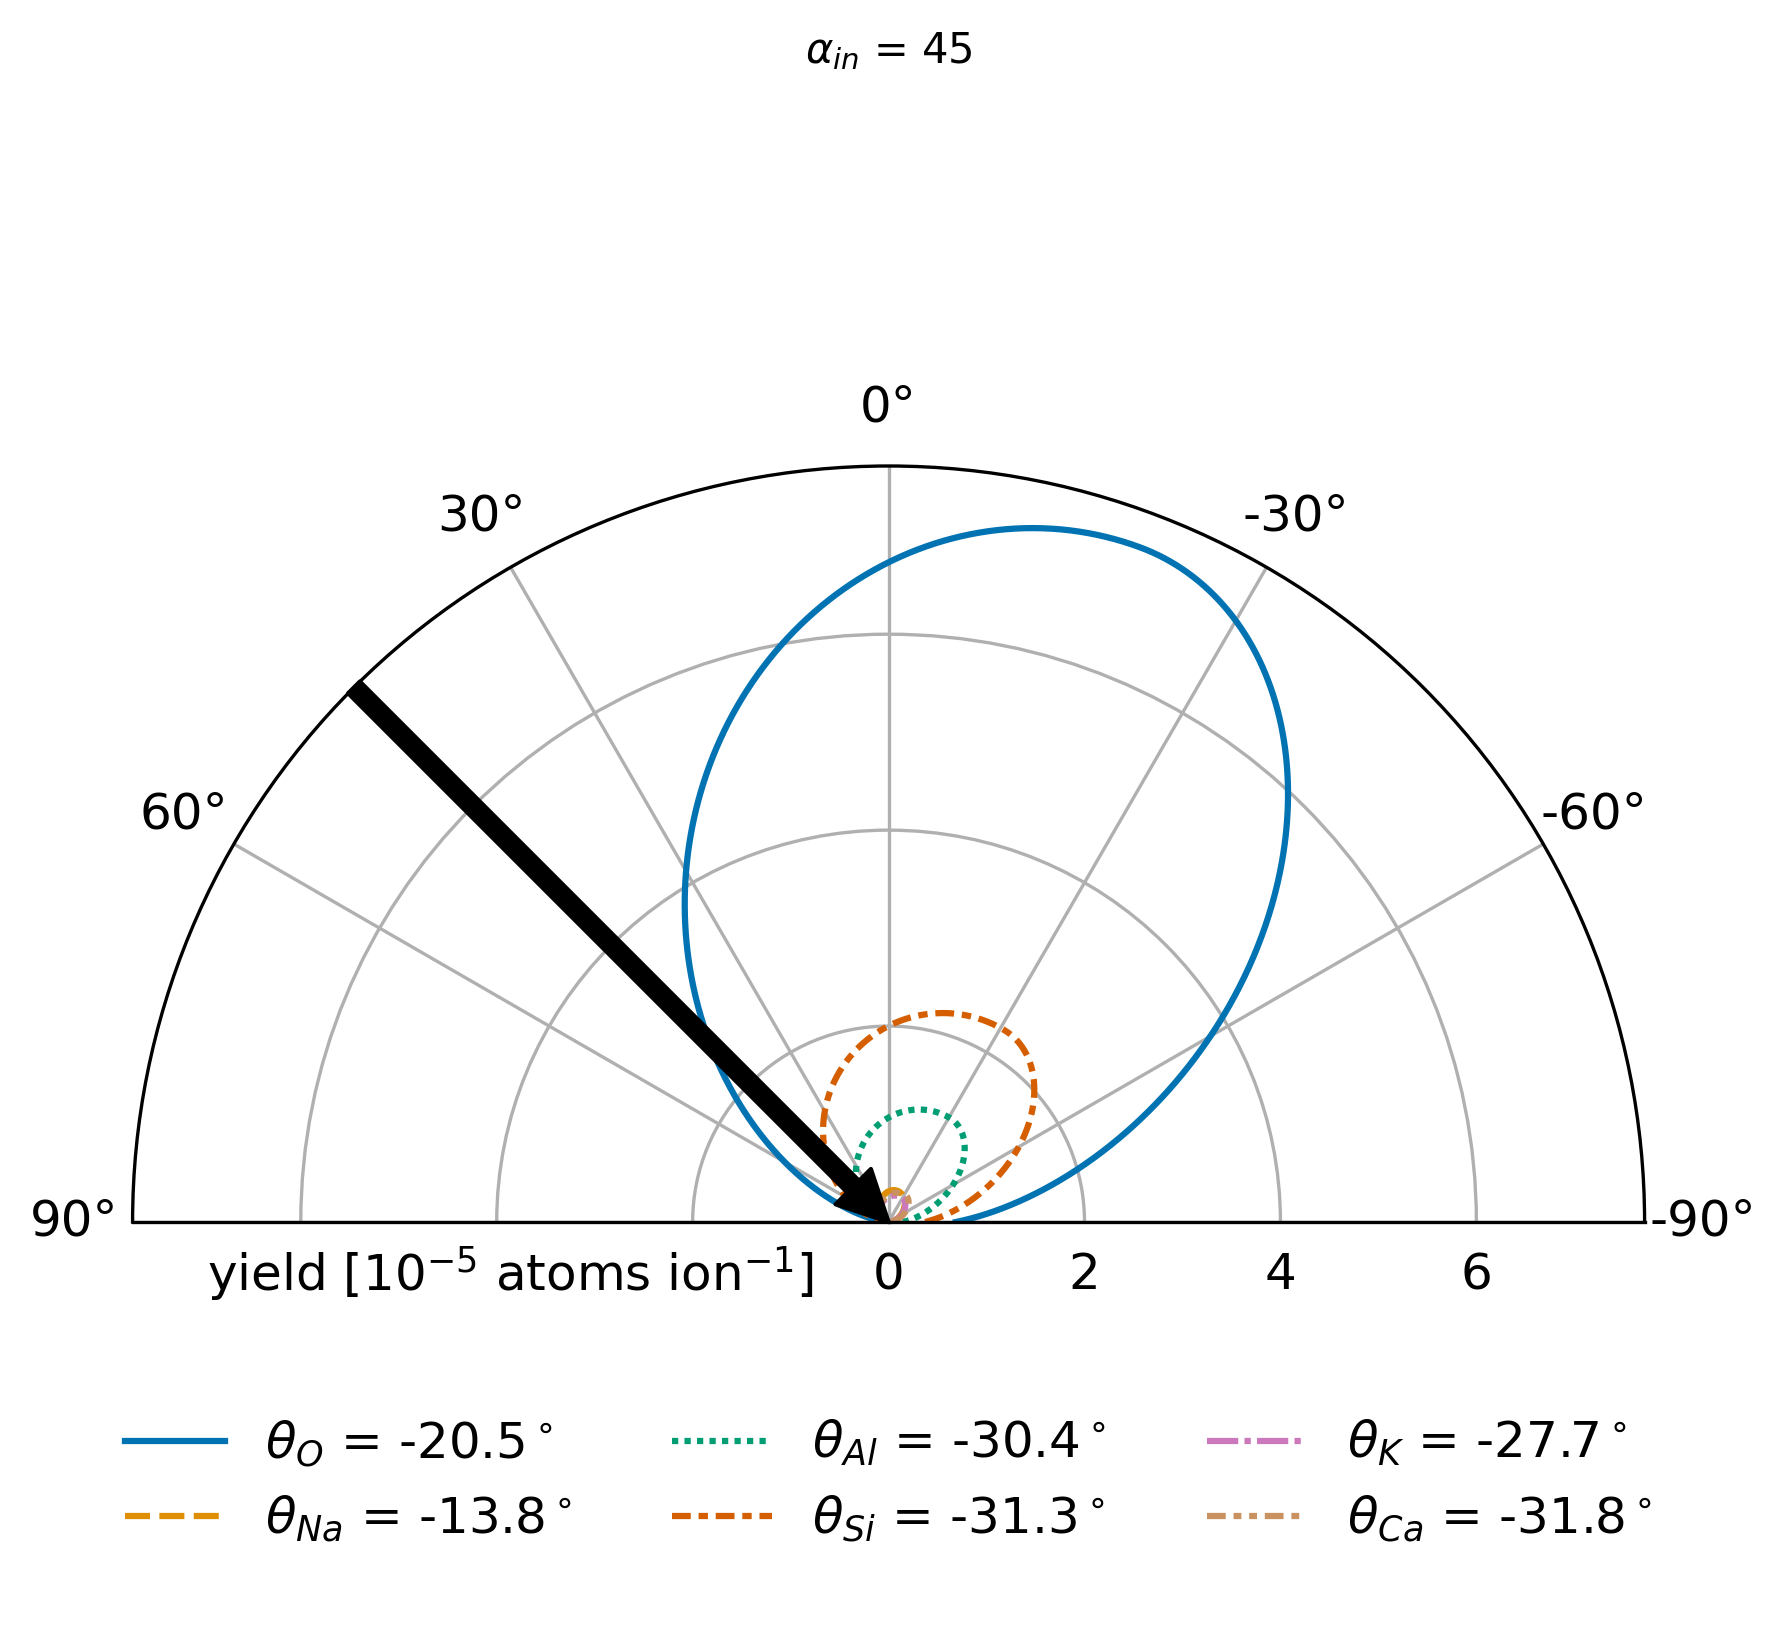

In [11]:
fig_adist, ax_adist = SpuBase.plot_dist('angular', title='')
fig_adist

Plotting energy distribution


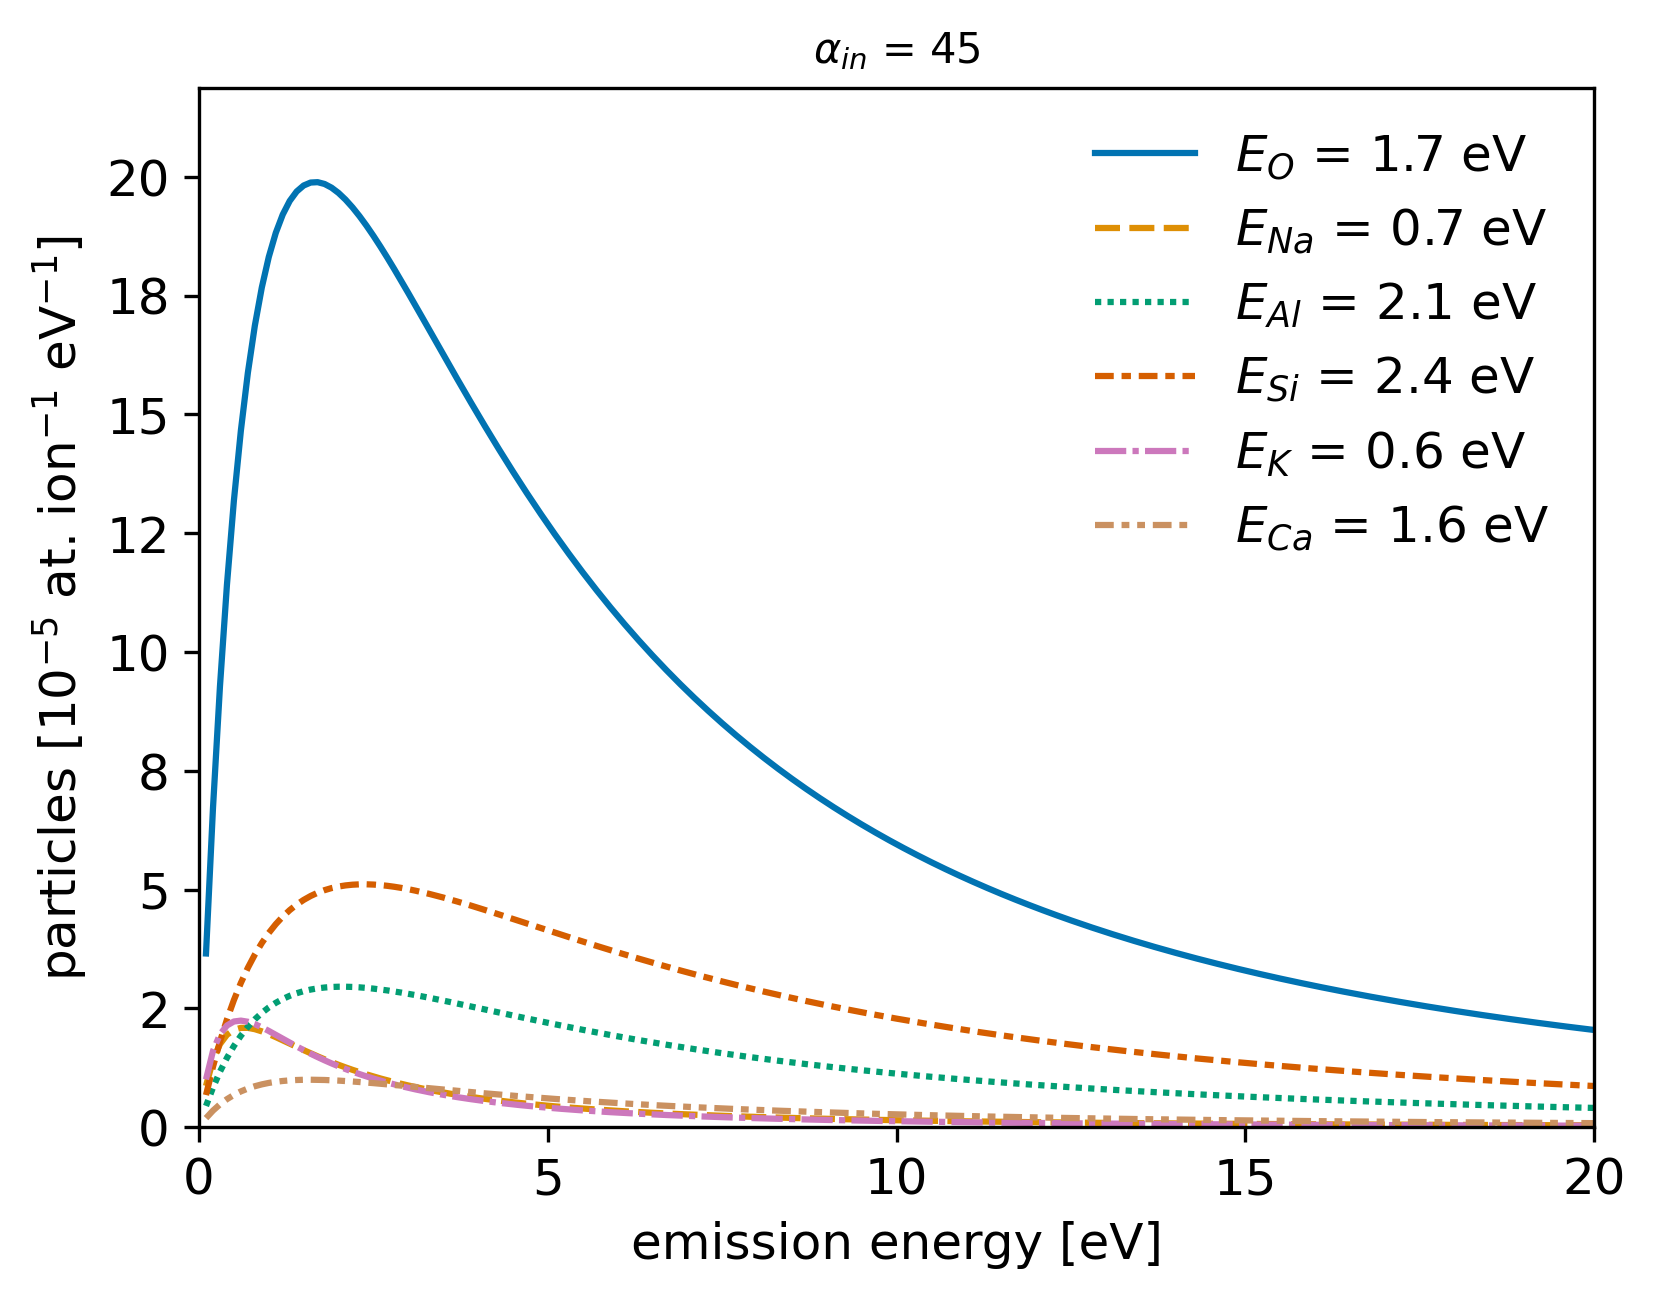

In [12]:
fig_edist, ax_edist = SpuBase.plot_dist('energy', title='')
fig_edist

Plotting plume distribution


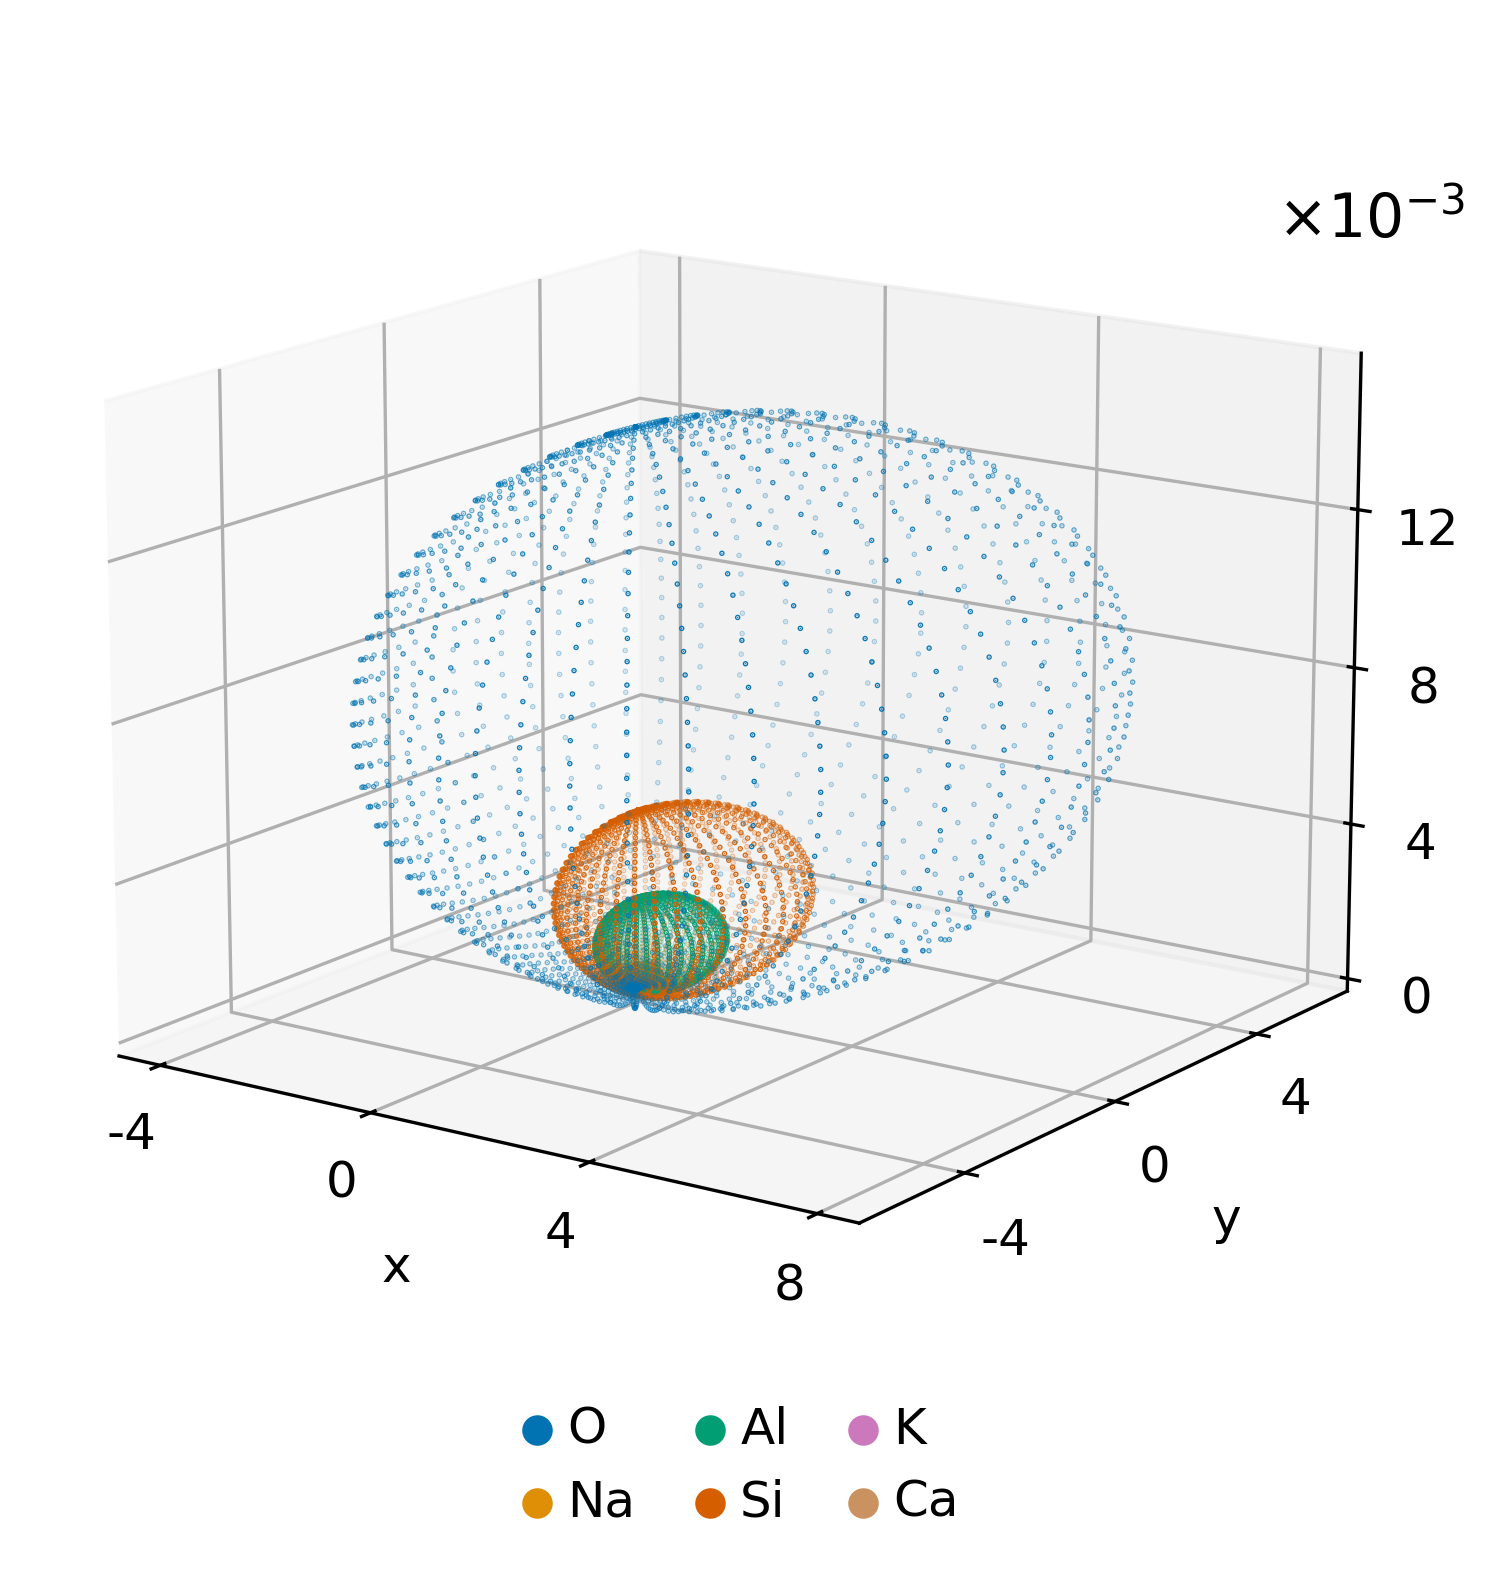

In [13]:
fig_pdist, ax_pdist = SpuBase.plot_dist('plume', title='', elev=15, azim=-55)
fig_pdist

Plotting surface_plume distribution


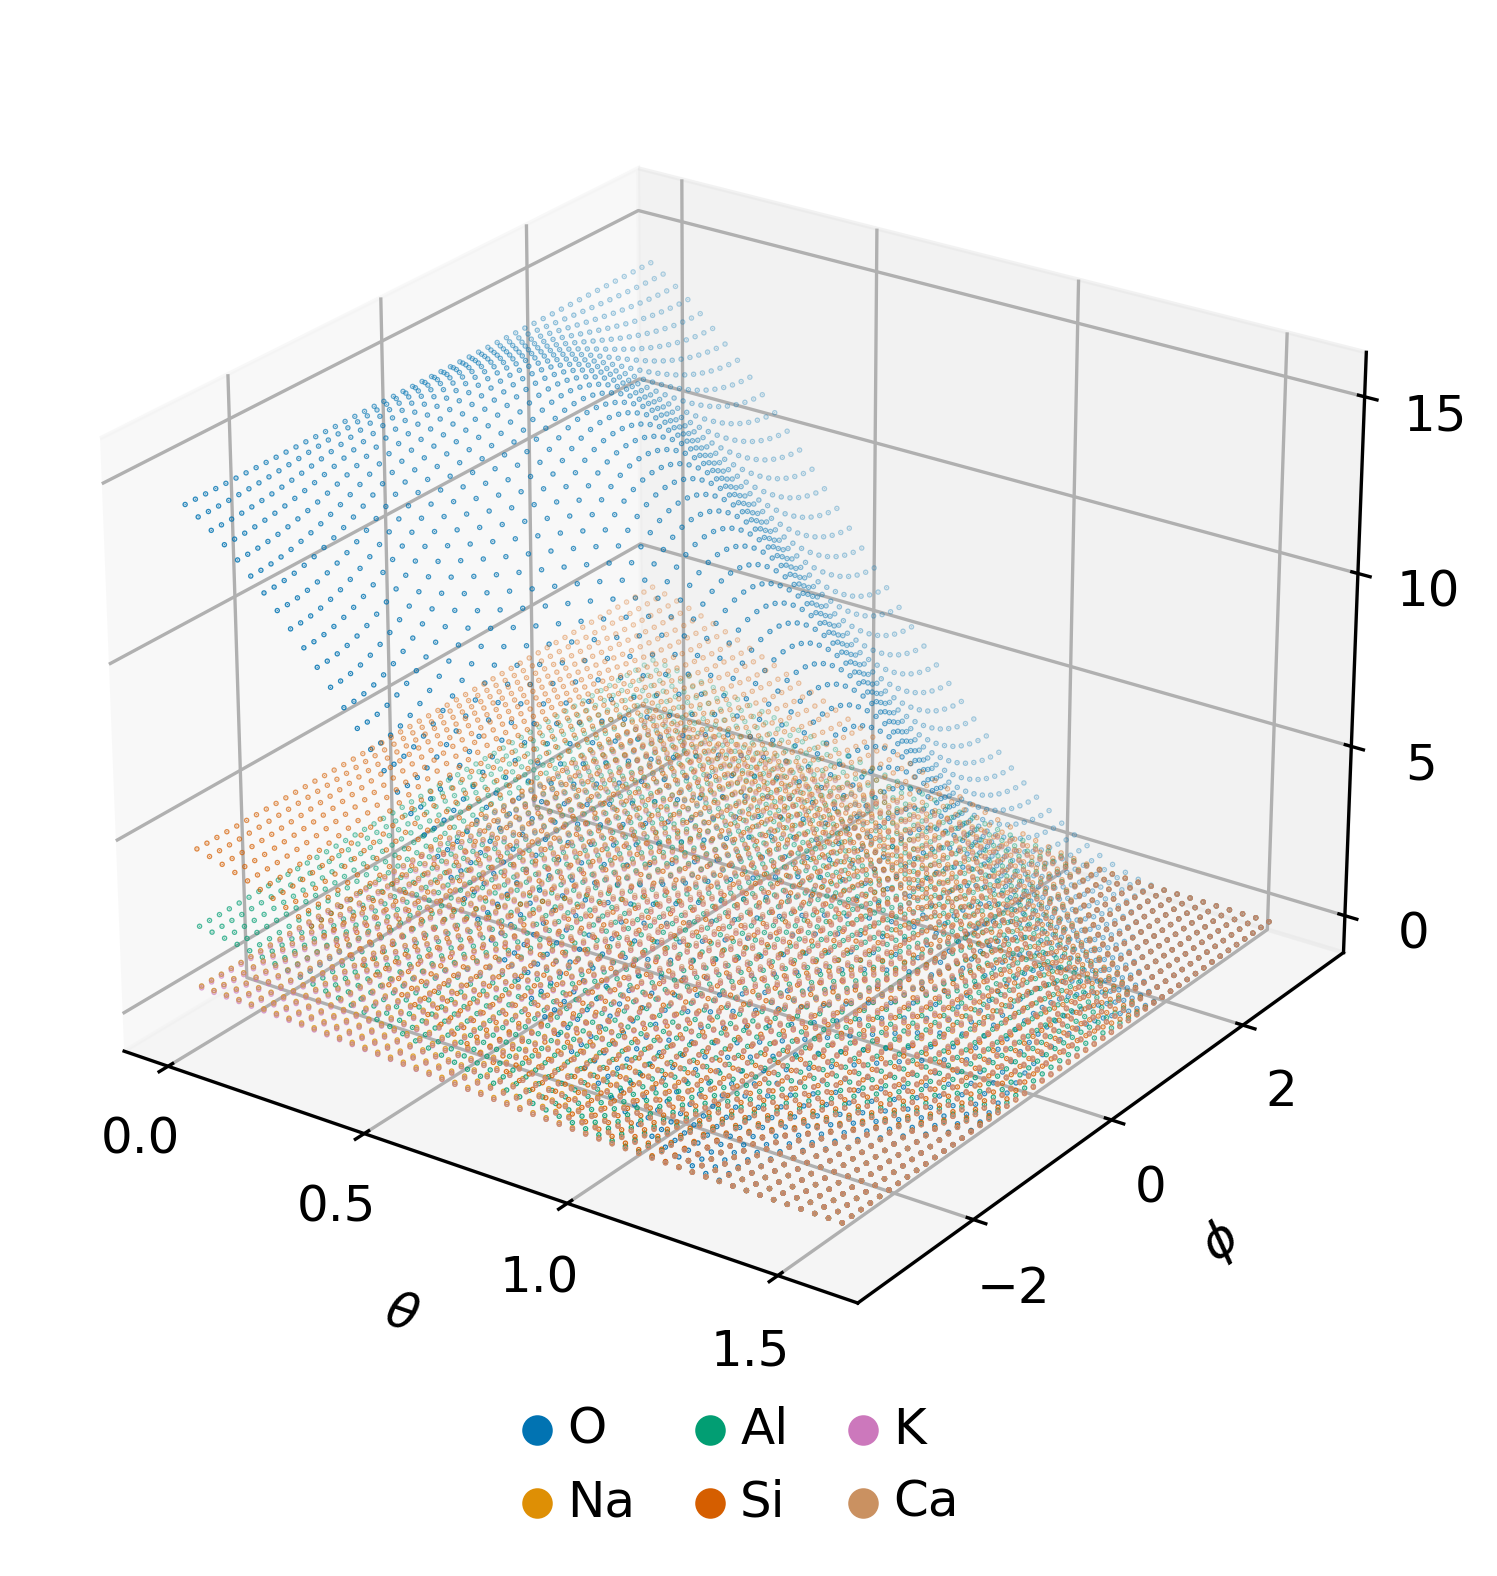

In [14]:
fig_psdist, ax_psdist = SpuBase.plot_dist('surface_plume', title='', elev=25, azim=-55)
fig_psdist